In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# Khánh

In [ ]:
import kagglehub
import os

path_to_dataset_dir = kagglehub.dataset_download("uciml/mushroom-classification")
csv_file_path = os.path.join(path_to_dataset_dir, 'mushrooms.csv')
df = pd.read_csv(csv_file_path)
df.head()

Using Colab cache for faster access to the 'mushroom-classification' dataset.


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
X_raw = df.drop('class', axis=1)
y_raw = df['class']

le = LabelEncoder()
y = le.fit_transform(y_raw)
X = pd.get_dummies(X_raw, drop_first=True, dtype=int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ml_models = {
    "1. Decision Tree (ID3/Entropy)": DecisionTreeClassifier(criterion='entropy', random_state=42),
    "2. Decision Tree (CART/Gini)": DecisionTreeClassifier(criterion='gini', random_state=42),
    "3. Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=42)
}

y_probs_dict = {}
results_list = []

In [ ]:
tf.random.set_seed(42)
input_dim = X_train.shape[1]
print("--- ĐANG HUẤN LUYỆN AUTOENCODER (PRE-TRAINING) ---")
input_layer = Input(shape=(input_dim,))
# Encoder
encoded = Dense(64, activation='relu')(input_layer)
bottleneck = Dense(16, activation='relu', name='encoder_output')(encoded)
# Decoder
decoded = Dense(64, activation='relu')(bottleneck)
output_layer = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(X_train, X_train, epochs=20, batch_size=64, validation_split=0.2, verbose=0)

--- ĐANG HUẤN LUYỆN AUTOENCODER (PRE-TRAINING) ---


In [ ]:
print("--- ĐANG HUẤN LUYỆN TRANSFER LEARNING MODEL ---")
# Trích xuất Encoder từ Autoencoder
encoder_model = Model(inputs=autoencoder.input, outputs=autoencoder.get_layer('encoder_output').output)

# Đóng băng (Freeze) các lớp của Encoder để giữ nguyên tri thức đã chuyển giao
for layer in encoder_model.layers:
    layer.trainable = False

# Xây dựng mô hình phân lớp mới trên nền Encoder
transfer_model = Sequential([
    encoder_model,
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

transfer_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
transfer_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=0)

print("Hoàn tất Transfer Learning!")

--- ĐANG HUẤN LUYỆN TRANSFER LEARNING MODEL ---
Hoàn tất Transfer Learning!


In [ ]:
# Đánh giá 3 mô hình ML cổ điển
for name, model in ml_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_probs_dict[name] = y_prob

    results_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

# Đánh giá mô hình Transfer Learning (Mạng Nơ-ron)
y_prob_nn = transfer_model.predict(X_test).ravel()
y_pred_nn = (y_prob_nn > 0.5).astype(int)
y_probs_dict["4. Backprop + Transfer Learning (NN)"] = y_prob_nn

results_list.append({
    "Model": "4. Backprop + Transfer Learning (NN)",
    "Accuracy": accuracy_score(y_test, y_pred_nn),
    "Precision": precision_score(y_test, y_pred_nn),
    "Recall": recall_score(y_test, y_pred_nn),
    "F1-Score": f1_score(y_test, y_pred_nn)
})

# Hiển thị Bảng kết quả
results_df = pd.DataFrame(results_list).round(4)
print("\n--- BẢNG SO SÁNH CÁC CHỈ SỐ MÔ HÌNH (LAB 4) ---")
display(results_df)

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- BẢNG SO SÁNH CÁC CHỈ SỐ MÔ HÌNH (LAB 4) ---


,Model,Accuracy,Precision,Recall,F1-Score
0,1. Decision Tree (ID3/Entropy),1.0000,1.0000,1.0000,1.0000
1,2. Decision Tree (CART/Gini),1.0000,1.0000,1.0000,1.0000
2,3. Gradient Boosting,0.9996,1.0000,0.9992,0.9996
3,4. Backprop + Transfer Learning (NN),0.9885,0.9915,0.9848,0.9881


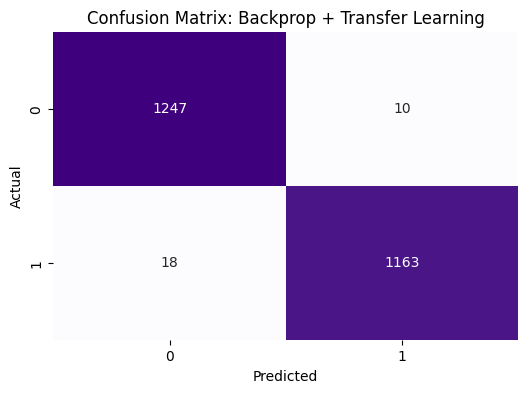

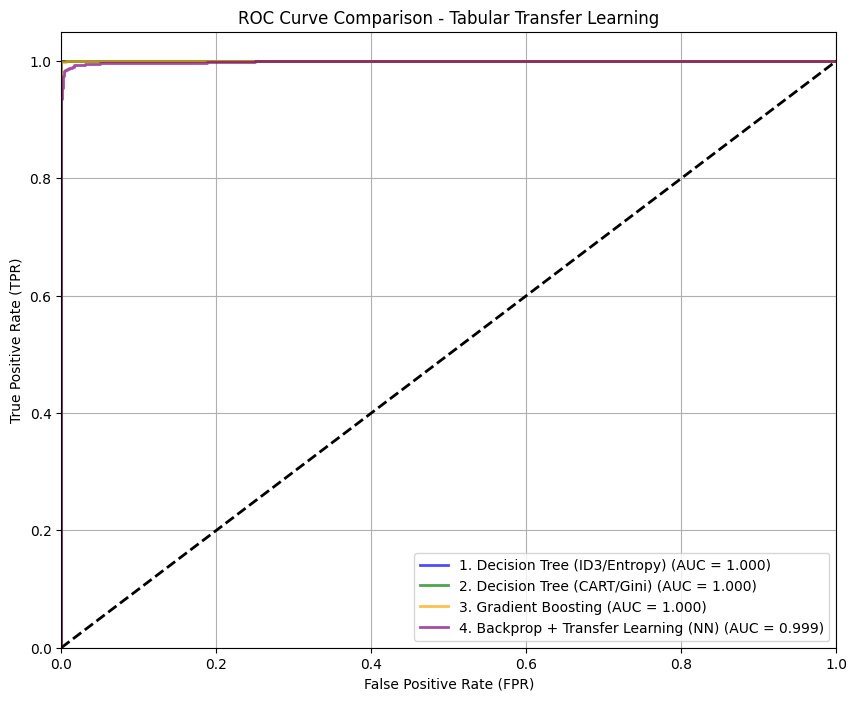

In [ ]:
# Vẽ Confusion Matrix cho mô hình Transfer Learning
cm_nn = confusion_matrix(y_test, y_pred_nn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('Confusion Matrix: Backprop + Transfer Learning')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Vẽ ROC Curve chung
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'orange', 'purple']

for (name, y_prob), color in zip(y_probs_dict.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    # Thêm chút nhiễu nhỏ vào nét vẽ để các đường ROC 100% không đè lấp hoàn toàn lên nhau
    plt.plot(fpr, tpr, lw=2, color=color, alpha=0.7, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison - Tabular Transfer Learning')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Huy

In [ ]:
# Load dataset
data = load_breast_cancer()
X_raw = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Chuẩn hóa dữ liệu (quan trọng cho Neural Networks)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X = pd.DataFrame(X_scaled, columns=data.feature_names)

# Chia tập dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Khởi tạo danh sách kết quả mới
ml_models_huy = {
    "1. Decision Tree (ID3/Entropy)": DecisionTreeClassifier(criterion='entropy', random_state=42),
    "2. Decision Tree (CART/Gini)": DecisionTreeClassifier(criterion='gini', random_state=42),
    "3. Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=42)
}

y_probs_dict_huy = {}
results_list_huy = []

display(X_raw.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
tf.random.set_seed(42)
input_dim_huy = X_train.shape[1]
print("--- HUẤN LUYỆN AUTOENCODER (BREAST CANCER) ---")

input_layer_h = Input(shape=(input_dim_huy,))
encoded_h = Dense(16, activation='relu')(input_layer_h)
bottleneck_h = Dense(8, activation='relu', name='encoder_output_huy')(encoded_h)
decoded_h = Dense(16, activation='relu')(bottleneck_h)
output_layer_h = Dense(input_dim_huy, activation='linear')(decoded_h)

autoencoder_huy = Model(inputs=input_layer_h, outputs=output_layer_h)
autoencoder_huy.compile(optimizer='adam', loss='mse')
autoencoder_huy.fit(X_train, X_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

print("--- HUẤN LUYỆN TRANSFER LEARNING (HUY) ---")
encoder_huy = Model(inputs=autoencoder_huy.input, outputs=autoencoder_huy.get_layer('encoder_output_huy').output)
for layer in encoder_huy.layers: layer.trainable = False

transfer_model_huy = Sequential([
    encoder_huy,
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])

transfer_model_huy.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
transfer_model_huy.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=0)
print("Hoàn tất quy trình")

--- HUẤN LUYỆN AUTOENCODER (BREAST CANCER) ---
--- HUẤN LUYỆN TRANSFER LEARNING (HUY) ---
Hoàn tất quy trình


In [ ]:
for name, model in ml_models_huy.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_probs_dict_huy[name] = y_prob
    results_list_huy.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

y_prob_nn_h = transfer_model_huy.predict(X_test).ravel()
y_pred_nn_h = (y_prob_nn_h > 0.5).astype(int)
y_probs_dict_huy["4. Backprop + Transfer Learning (NN)"] = y_prob_nn_h

results_list_huy.append({
    "Model": "4. Backprop + Transfer Learning (NN)",
    "Accuracy": accuracy_score(y_test, y_pred_nn_h),
    "Precision": precision_score(y_test, y_pred_nn_h),
    "Recall": recall_score(y_test, y_pred_nn_h),
    "F1-Score": f1_score(y_test, y_pred_nn_h)
})

results_df_huy = pd.DataFrame(results_list_huy).round(4)
print("\n--- BẢNG SO SÁNH KẾT QUẢ BREAST CANCER ---")
display(results_df_huy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

--- BẢNG SO SÁNH KẾT QUẢ BREAST CANCER ---


,Model,Accuracy,Precision,Recall,F1-Score
0,1. Decision Tree (ID3/Entropy),0.9649,0.9636,0.9815,0.9725
1,2. Decision Tree (CART/Gini),0.9415,0.9712,0.9352,0.9528
2,3. Gradient Boosting,0.9591,0.9633,0.9722,0.9677
3,4. Backprop + Transfer Learning (NN),0.9591,0.9810,0.9537,0.9671


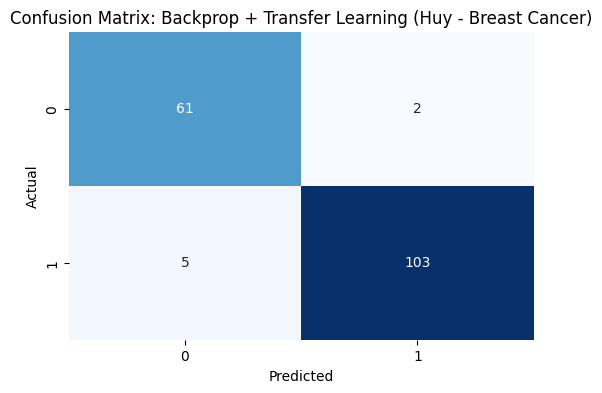

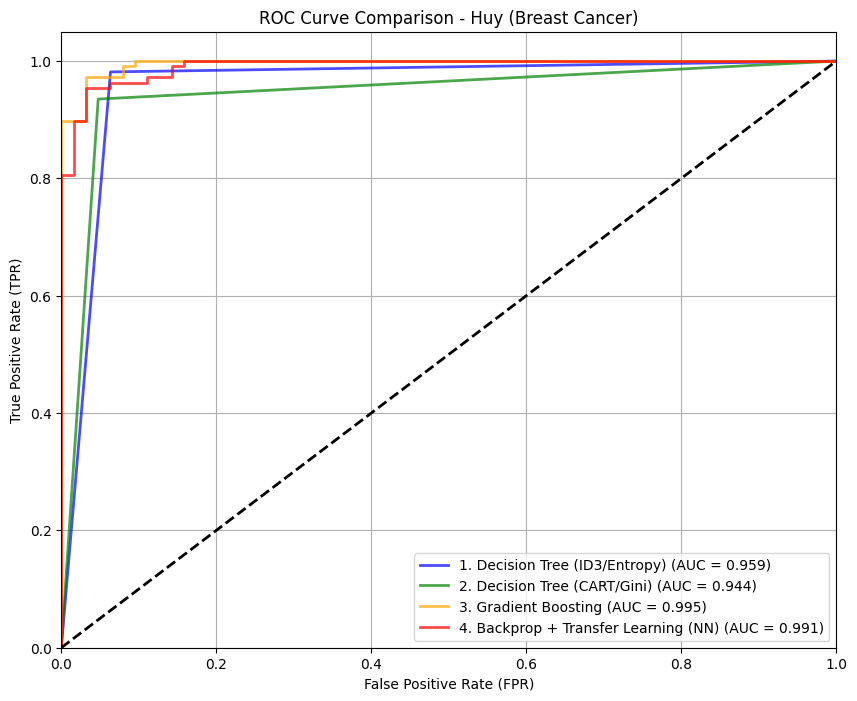

In [ ]:
# Vẽ Confusion Matrix cho mô hình Transfer Learning
cm_nn_h = confusion_matrix(y_test, y_pred_nn_h)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_nn_h, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix: Backprop + Transfer Learning (Huy - Breast Cancer)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Vẽ ROC Curve chung
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'orange', 'red']

for (name, y_prob), color in zip(y_probs_dict_huy.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=color, alpha=0.7, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison - Huy (Breast Cancer)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()